# Part A - Data Cleaning

In [1]:
# Imports and libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load Datasets
sentiment = pd.read_csv('fear_greed_index.csv')
trades = pd.read_csv('historical_data.csv')

print('Datasets Loaded Successfully!')

Datasets Loaded Successfully!


In [3]:
# Data Preparation
print('=' * 50)
print('SENTIMENT DATASET')
print('=' * 50)
print(f"Rows:        {sentiment.shape[0]}")
print(f"Columns:        {sentiment.shape[1]}")
print(f"\nMissing Values:\n{sentiment.isnull().sum()}")
print(f"\nDuplicates: {sentiment.duplicated().sum()}")
print(f"\nClassifications: {sentiment['classification'].unique()}")
print(f"Date Range: {sentiment['date'].min()} to {sentiment['date'].max()}")

print('\n' + '=' * 50)
print('TRADES DATASET')
print('=' * 50)
print(f"Rows:        {trades.shape[0]}")
print(f"Columns:        {trades.shape[1]}")
print(f"\nMissing Values:\n{trades.isnull().sum()}")
print(f"\nDuplicates: {trades.duplicated().sum()}")
print(f"\nUnique Accounts: {trades['Account'].nunique()}")
print(f"Unique Coins: {trades['Coin'].nunique()}")
print(f"Date Range: {trades['Timestamp IST'].min()} to {trades['Timestamp IST'].max()}")

SENTIMENT DATASET
Rows:        2644
Columns:        4

Missing Values:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicates: 0

Classifications: ['Fear' 'Extreme Fear' 'Neutral' 'Greed' 'Extreme Greed']
Date Range: 2018-02-01 to 2025-05-02

TRADES DATASET
Rows:        211224
Columns:        16

Missing Values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates: 0

Unique Accounts: 32
Unique Coins: 246
Date Range: 01-01-2024 01:23 to 31-12-2024 23:33


In [4]:
# Converting timestamps and merge
# Convert sentiment date to datetime
sentiment['date'] = pd.to_datetime(sentiment['date'])

# Extracting date from trades Timestamp IST
trades['date'] = pd.to_datetime(trades['Timestamp IST'], format='mixed', dayfirst=True).dt.normalize()
trades['date'] = pd.to_datetime(trades['date'])

# Filtering sentiment to 2024 only (trades date range)
sentiment_2024 = sentiment[
    (sentiment['date'] >= '2024-01-01') &
    (sentiment['date'] <= '2024-12-31')
].copy()

print(f"Sentiment 2024 rows: {len(sentiment_2024)}")
print(f"Trades rows: {len(trades)}")

Sentiment 2024 rows: 365
Trades rows: 211224


In [5]:
# Merge on date
df = trades.merge(sentiment_2024[['date', 'value', 'classification']], on='date', how='inner')
print(f"\nMerged dataset rows: {len(df)}")
print(f"Sentiment coverage:\n{df['classification'].value_counts()}")


Merged dataset rows: 52491
Sentiment coverage:
classification
Extreme Greed    29655
Greed            20092
Neutral           1293
Fear              1293
Extreme Fear       158
Name: count, dtype: int64


In [6]:
# Create Key Metrics

# 1. flag winnning trades (closed pnl > 0)
df['is_win'] = df['Closed PnL'] > 0

# 2. Daily PnL per trader
daily_pnl = df.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()
daily_pnl.columns = ['Account', 'date', 'daily_pnl']

# 3. Win rate per trader
win_rate = df.groupby('Account').apply(
    lambda x: (x['Closed PnL'] > 0).sum() / len(x)).reset_index()
win_rate.columns = ['Account', 'win_rate']

# 4. Average trade size per trader
avg_size = df.groupby('Account')['Size USD'].mean().reset_index()
avg_size.columns = ['Account', 'avg_trade_size']

# 5. Average leverage per trader
avg_leverage = df.groupby('Account')['Start Position'].mean().reset_index()
avg_leverage.columns = ['Account', 'avg_leverage']

# 6. Trades per day per trader
trades_per_day = df.groupby(['Account', 'date']).size().reset_index()
trades_per_day.columns = ['Account', 'date', 'trades_count']

# 7. Long/Short ratio per trader
long_short = df.groupby('Account').apply(
    lambda x: (x['Direction'] == 'Buy').sum() / len(x)).reset_index()
long_short.columns = ['Account', 'long_ratio']

In [7]:
# Combine all metrics into trader profile
trader_profile = win_rate \
    .merge(avg_size, on='Account') \
    .merge(avg_leverage, on='Account') \
    .merge(long_short, on='Account')

# Add total trades count
trade_counts = df.groupby('Account').size().reset_index()
trade_counts.columns =  ['Account', 'total_trades']
trader_profile = trader_profile.merge(trade_counts, on='Account')

# Add total PnL
total_pnl = df.groupby('Account')['Closed PnL'].sum().reset_index()
total_pnl.columns = ['Account', 'total_pnl']
trader_profile = trader_profile.merge(total_pnl, on='Account')

print(f"Trader profiles created: {len(trader_profile)}")
print(trader_profile.head())

Trader profiles created: 31
                                      Account  win_rate  avg_trade_size  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  0.025974    14810.891818   
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  0.531250     2492.749906   
2  0x271b280974205ca63b716753467d5a371de622ab  0.400000    19005.930000   
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4  0.436536      479.442805   
4  0x2c229d22b100a7beb69122eed721cee9b24011dd  0.505455     3001.041612   

    avg_leverage  long_ratio  total_trades      total_pnl  
0    -356.243942    0.000000           462 -327505.900056  
1    1888.982397    0.412500           320   20607.446093  
2      18.634970    0.000000            10    1792.160215  
3   15705.644589    0.143201          7067  126834.692494  
4  314851.847425    0.000000           825   54802.881666  


# Part B - Analysis Chart

In [8]:
# Question: Does PnL differ between Fear vs Greed days?

# Chart 1: Average Daily PnL by Sentiment Classification
# Merge daily_pnl with sentiment
daily_pnl_sentiment = daily_pnl.merge(sentiment_2024[['date', 'classification']], on='date', how ='inner')

# Average PnL per classification
pnl_by_sentiment = daily_pnl_sentiment.groupby('classification')['daily_pnl'].mean().reset_index()

# Order by sentiment level
order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
pnl_by_sentiment['classification'] = pd.Categorical(
    pnl_by_sentiment['classification'], categories=order, ordered=True
)
pnl_by_sentiment = pnl_by_sentiment.sort_values('classification')

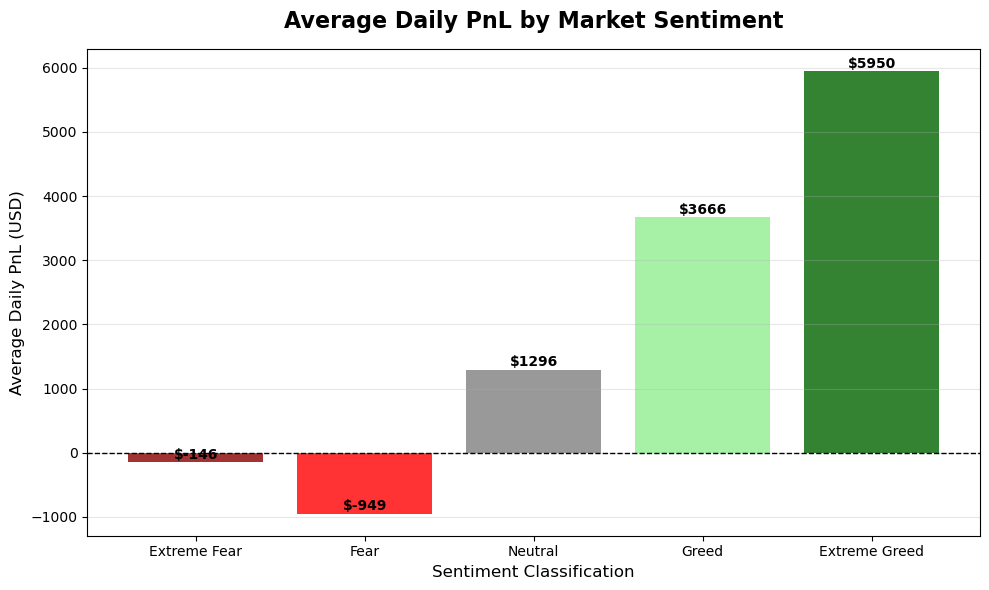

In [9]:
# Plot
fig, ax = plt.subplots(figsize=(10,6))
colors = ['darkred', 'red', 'grey', 'lightgreen', 'darkgreen']
bars = ax.bar(pnl_by_sentiment['classification'], pnl_by_sentiment['daily_pnl'], color=colors, alpha=0.8)

# Add value labels on bars
for bar, val in zip(bars, pnl_by_sentiment['daily_pnl']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height()+50,
            f'${val:.0f}', ha='center', fontsize=10, fontweight='bold')

ax.set_title("Average Daily PnL by Market Sentiment", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Sentiment Classification', fontsize=12)
ax.set_ylabel('Average Daily PnL (USD)', fontsize=12)
ax.axhline(y=0, color='black', linewidth=1, linestyle='--')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [10]:
# Question: Do Traders change behaviour on Fear vs Greed days?
# Chart 2: Trade Frequency by Sentiment

trades_per_sentiment = df.groupby('classification').size().reset_index()
trades_per_sentiment.columns = ['classification', 'trade_count']

# Order by sentiment
trades_per_sentiment['classification'] = pd.Categorical(
    trades_per_sentiment['classification'], categories=order, ordered=True
)
trades_per_sentiment = trades_per_sentiment.sort_values('classification')

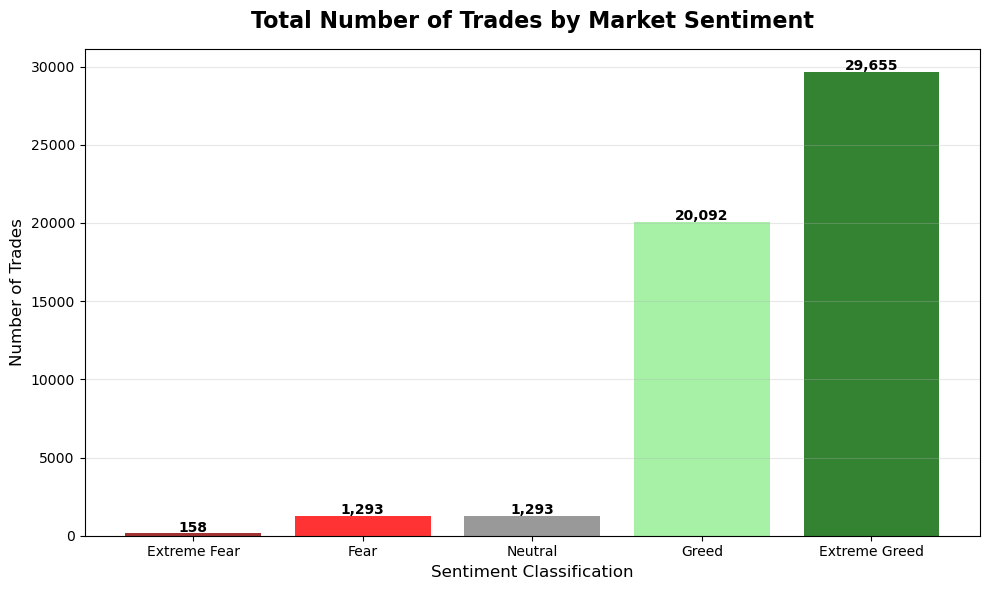

In [11]:
# Plot 
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(trades_per_sentiment['classification'],
              trades_per_sentiment['trade_count'],
              color=colors, alpha=0.8)

for bar, val in zip(bars, trades_per_sentiment['trade_count']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 100,
            f'{val:,}', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Total Number of Trades by Market Sentiment',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Sentiment Classification', fontsize=12)
ax.set_ylabel('Number of Trades', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

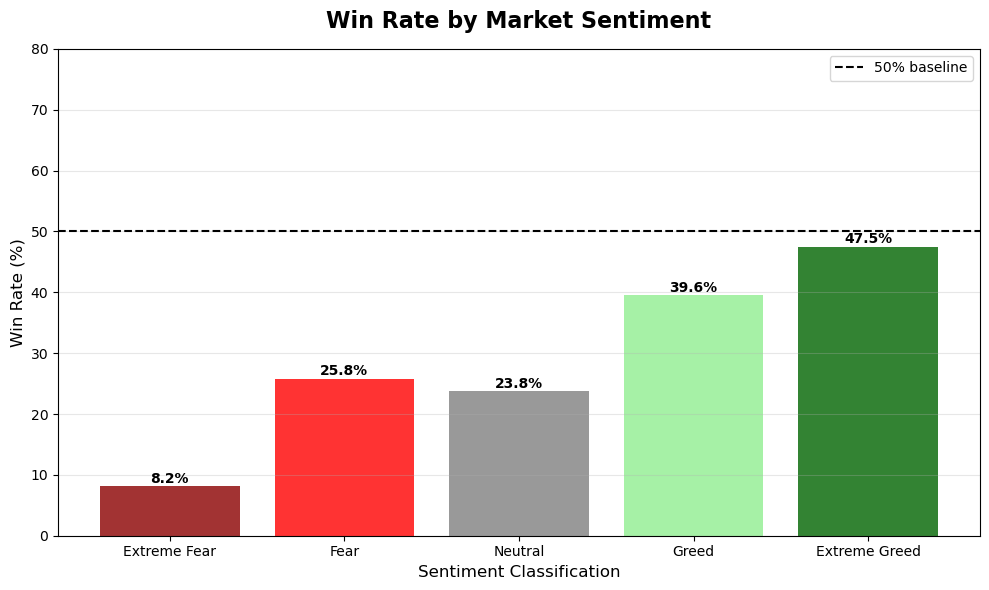

In [12]:
# Chart 3: Win Rate by Sentiment

win_rate_sentiment = df.groupby('classification').apply(
    lambda x: (x['Closed PnL'] > 0).sum() / len(x) * 100
).reset_index()
win_rate_sentiment.columns = ['classification', 'win_rate_pct']

win_rate_sentiment['classification'] = pd.Categorical(
    win_rate_sentiment['classification'], categories=order, ordered=True
)
win_rate_sentiment = win_rate_sentiment.sort_values('classification')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(win_rate_sentiment['classification'],
              win_rate_sentiment['win_rate_pct'],
              color=colors, alpha=0.8)

for bar, val in zip(bars, win_rate_sentiment['win_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

ax.axhline(y=50, color='black', linewidth=1.5, 
           linestyle='--', label='50% baseline')
ax.set_title('Win Rate by Market Sentiment',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Sentiment Classification', fontsize=12)
ax.set_ylabel('Win Rate (%)', fontsize=12)
ax.set_ylim(0, 80)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

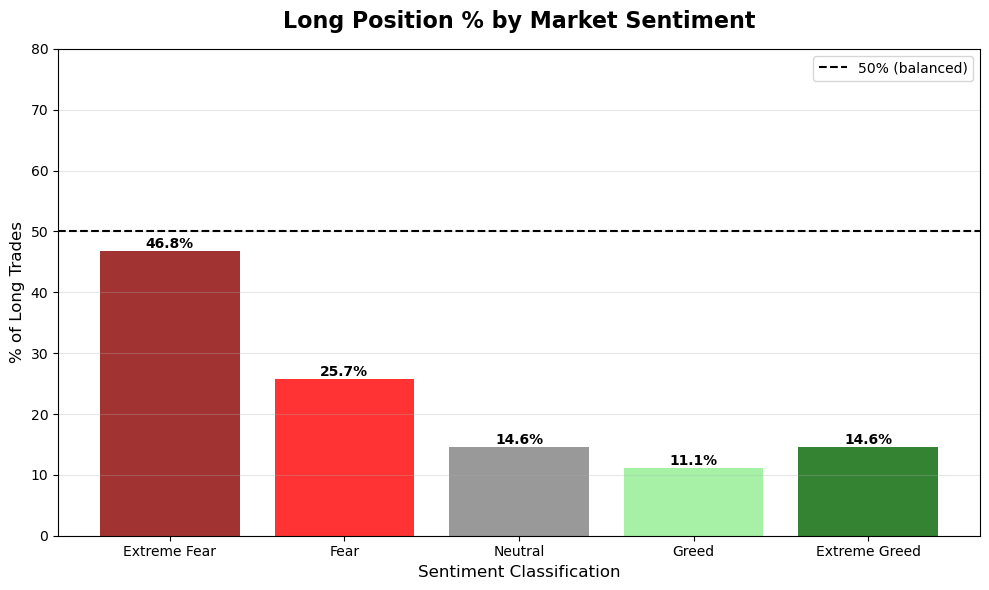

In [13]:
# Chart 4: Long/Short Ratio by Sentiment

long_short_sentiment = df.groupby('classification').apply(
    lambda x: (x['Direction'] == 'Buy').sum() / len(x) * 100
).reset_index()
long_short_sentiment.columns = ['classification', 'long_pct']

long_short_sentiment['classification'] = pd.Categorical(
    long_short_sentiment['classification'], categories=order, ordered=True
)
long_short_sentiment = long_short_sentiment.sort_values('classification')

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(long_short_sentiment['classification'],
              long_short_sentiment['long_pct'],
              color=colors, alpha=0.8)

for bar, val in zip(bars, long_short_sentiment['long_pct']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

ax.axhline(y=50, color='black', linewidth=1.5,
           linestyle='--', label='50% (balanced)')
ax.set_title('Long Position % by Market Sentiment',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Sentiment Classification', fontsize=12)
ax.set_ylabel('% of Long Trades', fontsize=12)
ax.set_ylim(0, 80)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

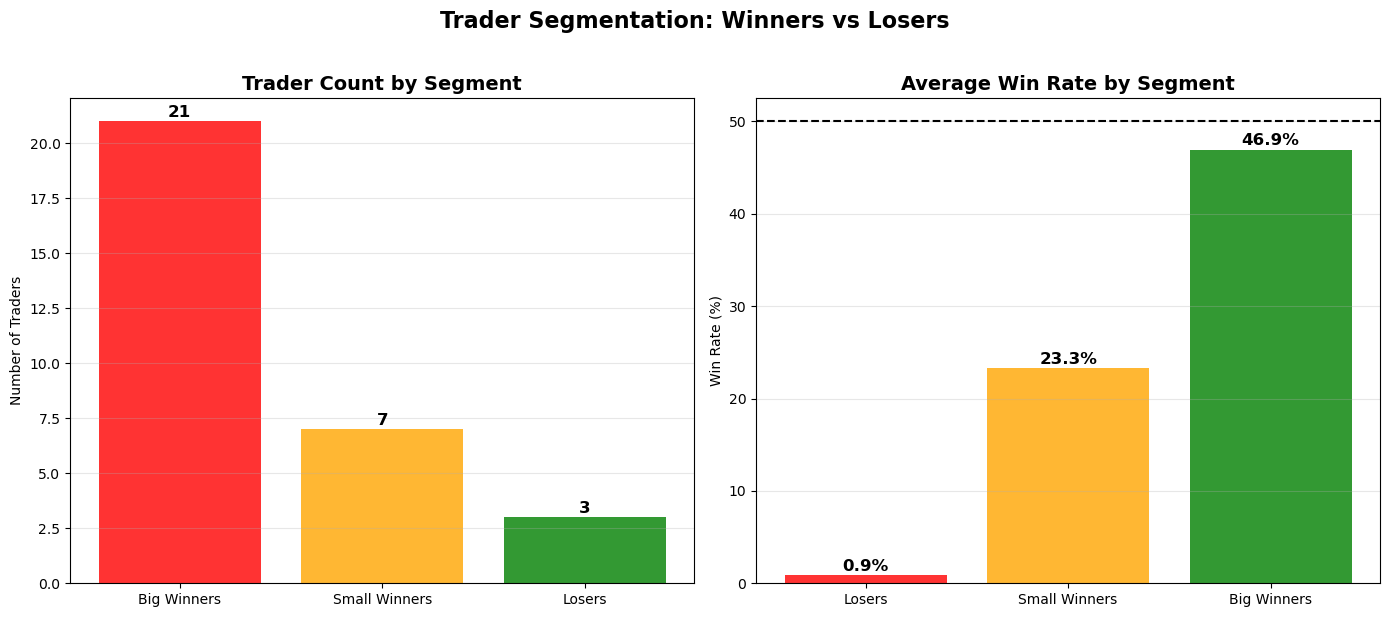

                   total_pnl  win_rate  total_trades
segment                                             
Losers        -109168.653605  0.008658    229.666667
Small Winners    3394.328661  0.232554    194.571429
Big Winners    184196.796133  0.469450   2401.904762


In [14]:
# Chart 5: Trader Segments — Winners vs Losers

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Segment by total PnL
trader_profile['segment'] = pd.cut(
    trader_profile['total_pnl'],
    bins=[-float('inf'), 0, 10000, float('inf')],
    labels=['Losers', 'Small Winners', 'Big Winners']
)

# Left chart — PnL distribution
segment_counts = trader_profile['segment'].value_counts()
axes[0].bar(segment_counts.index, segment_counts.values,
            color=['red', 'orange', 'green'], alpha=0.8)
for i, (idx, val) in enumerate(segment_counts.items()):
    axes[0].text(i, val + 0.2, str(val), 
                ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Trader Count by Segment',
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Traders')
axes[0].grid(True, alpha=0.3, axis='y')

# Right chart — Win rate by segment
win_by_segment = trader_profile.groupby('segment')['win_rate'].mean() * 100
axes[1].bar(win_by_segment.index, win_by_segment.values,
            color=['red', 'orange', 'green'], alpha=0.8)
for i, (idx, val) in enumerate(win_by_segment.items()):
    axes[1].text(i, val + 0.5, f'{val:.1f}%',
                ha='center', fontsize=12, fontweight='bold')
axes[1].axhline(y=50, color='black', linewidth=1.5, linestyle='--')
axes[1].set_title('Average Win Rate by Segment',
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('Win Rate (%)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Trader Segmentation: Winners vs Losers',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(trader_profile.groupby('segment')[['total_pnl', 'win_rate', 'total_trades']].mean())

## Part C — Actionable Strategy Recommendations

### Strategy Rule 1: Sentiment-Based Position Sizing
Trade larger positions on Extreme Greed days and reduce 
position sizes on Fear days.

Evidence: Average daily PnL on Extreme Greed days (USD 5,950) is 
6x higher than Neutral days (USD 1,296). Traders who followed 
the market mood earned significantly more.

Rule: 
- Extreme Greed → use 100% of normal position size
- Greed → use 75% of normal position size  
- Neutral → use 50% of normal position size
- Fear → use 25% of normal position size
- Extreme Fear → sit out or hedge only

### Strategy Rule 2: Win Rate is a Trap — Focus on Risk/Reward
Do not optimize for win rate. Optimize for reward-to-risk ratio.

Evidence: Big Winners averaged only 46.9% win rate but earned 
USD 184,196 on average. Losers had 0.9% win rate and lost 
USD 109,168. The difference is cutting losses fast and 
holding winning trades longer.

Rule:
- Set hard stop loss at 1% of position per trade
- Only exit winning trades at 2%+ gain (2:1 reward/risk minimum)
- Never average down on losing trades
- Be most aggressive on Extreme Greed days (highest win probability)

# Bonus K-Means Clustering

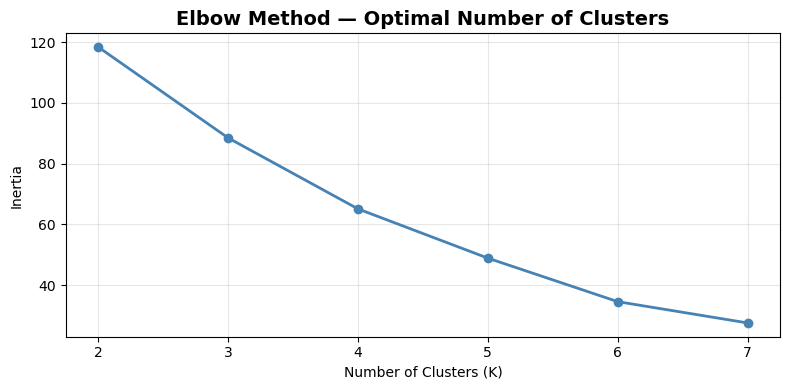

In [15]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_features = trader_profile[['win_rate', 'avg_trade_size', 
                                    'total_trades', 'total_pnl', 
                                    'long_ratio']].copy().reset_index(drop=True)

cluster_features = cluster_features.astype(float)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

inertias = []
k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, 
                    n_init=10, algorithm='lloyd')
    kmeans.fit(scaled_features)
    inertias.append(kmeans.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_range, inertias, marker='o', color='steelblue', linewidth=2)
ax.set_title('Elbow Method — Optimal Number of Clusters',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

         win_rate  avg_trade_size  total_trades     total_pnl  long_ratio
cluster                                                                  
0        0.375782     2690.025162       1232.00  5.169607e+04    0.226450
1        0.426626     4316.115542       8556.00  1.088096e+06    0.213287
2        0.316128    15995.506080       1144.75  2.394855e+04    0.000000


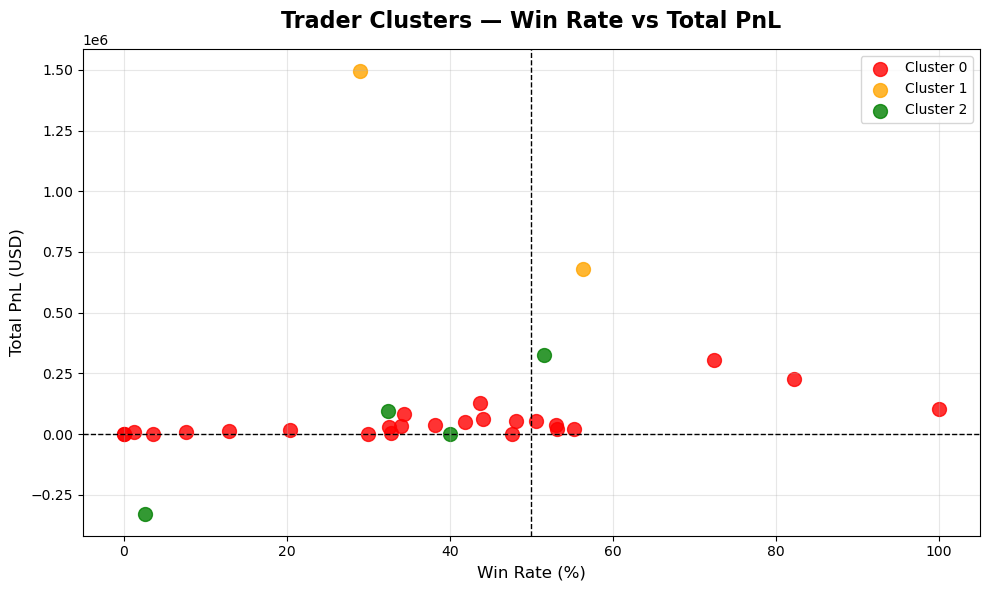

In [17]:
# Apply KMeans with K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
trader_profile['cluster'] = kmeans.fit_predict(scaled_features)

# Profile each cluster
cluster_summary = trader_profile.groupby('cluster')[
    ['win_rate', 'avg_trade_size', 'total_trades', 
     'total_pnl', 'long_ratio']].mean()

print(cluster_summary)

# Plot clusters — PnL vs Win Rate
fig, ax = plt.subplots(figsize=(10, 6))

colors_cluster = ['red', 'orange', 'green']
labels = ['Cluster 0', 'Cluster 1', 'Cluster 2']

for i in range(3):
    mask = trader_profile['cluster'] == i
    ax.scatter(trader_profile[mask]['win_rate'] * 100,
               trader_profile[mask]['total_pnl'],
               color=colors_cluster[i], s=100,
               alpha=0.8, label=f'Cluster {i}')

ax.axhline(y=0, color='black', linewidth=1, linestyle='--')
ax.axvline(x=50, color='black', linewidth=1, linestyle='--')
ax.set_title('Trader Clusters — Win Rate vs Total PnL',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Win Rate (%)', fontsize=12)
ax.set_ylabel('Total PnL (USD)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Trader Segmentation using K-Means Clustering

Using K-Means Clustering, traders were grouped into three behavioral segments based on their trading performance and activity metrics.

Cluster 0 — Moderate Traders
This group represents the majority of traders with moderate win rates and relatively small trade sizes. Their trading activity and profitability are limited, indicating typical retail trading behavior with balanced risk exposure.

Cluster 1 — High-Frequency Profitable Traders
Traders in this cluster execute the highest number of trades and generate the largest cumulative PnL. Despite only slightly higher win rates, their consistent trading activity allows them to accumulate significant profits.

Cluster 2 — High-Risk Speculative Traders
This cluster is characterized by very large trade sizes but lower win rates. These traders appear to take aggressive positions, leading to higher volatility and inconsistent profitre volatile outcomes.fitability.
itability.
itability.
itability.


# Key Insight

The clustering analysis shows that traders who maintain higher trading frequency with controlled position sizes tend to achieve more consistent profitability, while traders relying on large speculative positions often experience more volatile outcomes.